In [ ]:
#bibliotecas para modelagem de dados
import pandas as pd
import numpy as np

#bibliotecas para analises graficas
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from cycler import cycler

In [ ]:
#Criar paleta personalizada
netflix_palette = [
    "#e5383b",
    "#a2010b",
    "#e8843f",
    "#0f6092",
    "#010103",
    "#F1948A",
    "#85929E"
]

plt.rcParams['axes.prop_cycle'] = cycler(color=netflix_palette)

#Análises - Data de lançamento
**Arquivo**: dataset_final.csv

In [ ]:
#Visualização do dataset enriquecido
df = pd.read_csv('dataset_final.csv')

In [ ]:
#Lançamentos por estacao
df_estacoes = df.groupby(df["estacao"])["id"].count().sort_values(ascending=False)
df_estacoes

,id
estacao,
Primavera,2421
Verão,1943
Inverno,1935
Outono,1911
Não informado,597


In [ ]:
df["adicionado_em"] = pd.to_datetime(df["adicionado_em"])
#Inclusos no catálogo por ano
df_por_ano = df.groupby(df["adicionado_em"].dt.year)["id"].count().sort_values(ascending=False)
df_por_ano

,id
adicionado_em,
2019.0,1999
2020.0,1878
2018.0,1625
2021.0,1498
2017.0,1164
2016.0,418
2015.0,73
2014.0,23
2011.0,13


In [ ]:
#Inclusos no catálogo por mês
df_por_mes = df.groupby(df["adicionado_em"].dt.month)["id"].count()
df_por_mes

,id
adicionado_em,
1.0,727
2.0,557
3.0,734
4.0,759
5.0,626
6.0,724
7.0,819
8.0,749
9.0,765


<Axes: xlabel='adicionado_em'>

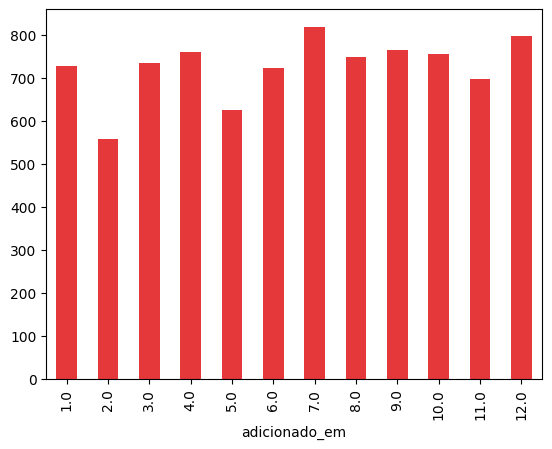

In [ ]:
#Gráfico - inclusos no catalogo por mês

plt.figure()
df_por_mes.plot(kind="bar")

<Axes: xlabel='estacao'>

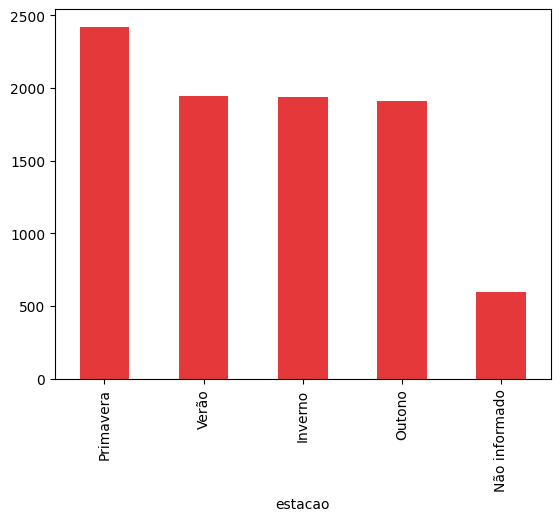

In [ ]:
#Gráfico - lançamentos por estacoes
plt.figure()
df_estacoes.plot(kind="bar")

<Axes: xlabel='adicionado_em'>

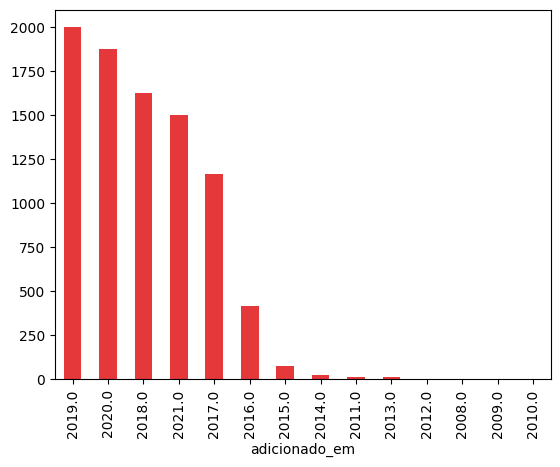

In [ ]:
#Gráfico - inclusos no catalogo por ano
plt.figure()
df_por_ano.plot(kind="bar")

Text(0.5, 0, 'Ano de lançamento')

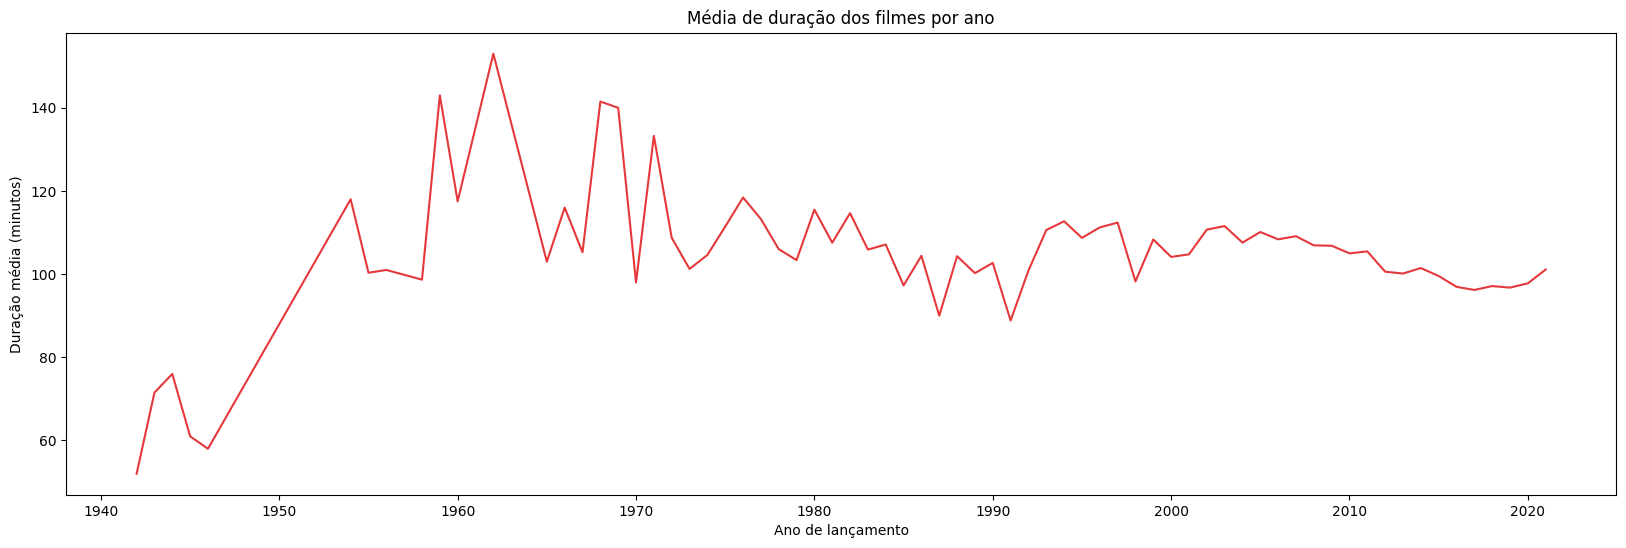

In [ ]:
#Criar df_filmes
df_filmes = df[df['tipo'] == 'Movie']

#Média de duração por ano excluindo outliers

#Retirando outliers
Q1 = df_filmes["duracao_em_min"].quantile(0.25)
Q3 = df_filmes["duracao_em_min"].quantile(0.75)

IQR = Q3 - Q1

limite_inf = Q1 - 1.5 * IQR
limite_sup = Q3 + 1.5 * IQR

df_filmes_sem_outlier = df_filmes[(df_filmes["duracao_em_min"] >= limite_inf) & (df_filmes["duracao_em_min"] <= limite_sup)]


#Calculando a média
duracao_media_ano = (
    df_filmes_sem_outlier
    .groupby("ano_lancamento")["duracao_em_min"]
    .mean()
    .reset_index()
)


#Plot do gráfico
plt.figure(figsize=(20,6))
plt.title('Média de duração dos filmes por ano')

sns.lineplot(data=duracao_media_ano, x="ano_lancamento", y="duracao_em_min")

plt.ylabel("Duração média (minutos)")
plt.xlabel("Ano de lançamento")

# Comparações com top 10 do Tudum
Os dataframes a seguir foram criados em 11/03/2026 a partir das informações disponíveis para download no Tudum da Neftlix: https://www.netflix.com/tudum/top10/brazil. Uma cópia dos CSVs utilizados, já filtrados pelo Brasil e separados em filmes e séries, estão disponíveis no repositório.

**Arquivos utilizados**

* df_filmes.csv
* df_series.csv

### Filmes

In [ ]:
#Criar os dfs de filmes e séries
df_filmes = pd.read_csv('df_filmes.csv')
df_series = pd.read_csv('df_series.csv')

In [ ]:
#Criar coluna ano
df_filmes = df_filmes.assign(ano=df_filmes['week'].str[:4])
df_filmes.head()

,country_name,country_iso2,week,category,weekly_rank,show_title,season_title,cumulative_weeks_in_top_10,ano
39200,Brazil,BR,2026-03-08,Films,1,War Machine,NaN,1,2026
39201,Brazil,BR,2026-03-08,Films,2,Hierarchy,NaN,2,2026
39202,Brazil,BR,2026-03-08,Films,3,#SalveRosa,NaN,2,2026
39203,Brazil,BR,2026-03-08,Films,4,The Karate Kid,NaN,1,2026
39204,Brazil,BR,2026-03-08,Films,5,Accused,NaN,2,2026


In [ ]:
df_filmes['show_title'].value_counts(0)

,count
show_title,
KPop Demon Hunters,24
Paw Patrol: The Movie,11
Dr. Seuss' The Grinch,10
Hotel Transylvania 3: Summer Vacation,10
The Secret Life of Pets 2,9
...,...
What's Your Number?,1
They Cloned Tyrone,1
World War Z,1


In [ ]:
#3 filmes mais assistidos de cada ano
df_top_filmes_por_ano = df_filmes.groupby('ano')['show_title'].value_counts().groupby(level=0).head(3)
df_top_filmes_por_ano

ano   show_title                           
2021  Red Notice                                6
      Hotel Transylvania 3: Summer Vacation     5
      Venom                                     4
2022  The Sea Beast                             6
      Sonic the Hedgehog                        5
      The Tinder Swindler                       5
2023  Paw Patrol: The Movie                     7
      Leo                                       6
      Woody Woodpecker                          6
2024  Ice Age: Dawn of the Dinosaurs            7
      Ferdinand                                 6
      PAW Patrol: The Mighty Movie              6
2025  KPop Demon Hunters                       22
      The Secret Life of Pets 2                 6
      The Super Mario Bros. Movie               6
2026  The Rip                                   4
      Firebreak                                 3
      Madagascar                                3
Name: count, dtype: int64

In [ ]:
#Transformar em dataframe
df_top_filmes_por_ano = df_top_filmes_por_ano.reset_index()
df_top_filmes_por_ano

,ano,show_title,count
0,2021,Red Notice,6
1,2021,Hotel Transylvania 3: Summer Vacation,5
2,2021,Venom,4
3,2022,The Sea Beast,6
4,2022,Sonic the Hedgehog,5
5,2022,The Tinder Swindler,5
6,2023,Paw Patrol: The Movie,7
7,2023,Leo,6
8,2023,Woody Woodpecker,6
9,2024,Ice Age: Dawn of the Dinosaurs,7


### Séries

In [ ]:
#Criar coluna ano
df_series = df_series.assign(ano=df_series['week'].str[:4])
df_series.head()

,country_name,country_iso2,week,category,weekly_rank,show_title,season_title,cumulative_weeks_in_top_10,ano
39210,Brazil,BR,2026-03-08,TV,1,Bridgerton,Bridgerton: Season 4,6,2026
39211,Brazil,BR,2026-03-08,TV,2,The Dinosaurs,The Dinosaurs: Season 1,1,2026
39212,Brazil,BR,2026-03-08,TV,3,The Mentalist,The Mentalist: Season 1,1,2026
39213,Brazil,BR,2026-03-08,TV,4,Teen Wolf,Teen Wolf: Season 1,1,2026
39214,Brazil,BR,2026-03-08,TV,5,Boyfriend on Demand,Boyfriend on Demand: Limited Series,1,2026


In [ ]:
df_series['show_title'].value_counts(0)

,count
show_title,
Lottie Dottie Chicken,126
Chiquititas,93
Stranger Things,63
Carrossel,53
Carinha de Anjo,42
...,...
Elves,1
The Mentalist,1
The Seven Deadly Sins,1


In [ ]:
df_series['season_title'].value_counts(0)

,count
season_title,
Lottie Dottie Chicken: 2ª temporada,126
Carinha de Anjo: Season 1,42
As Aventuras de Poliana: Season 1,37
Café con aroma de mujer: Season 1,23
Wednesday: Season 1,18
...,...
Lucifer: Season 5,1
Gabby's Dollhouse: Season 13,1
The Mentalist: Season 1,1


In [ ]:
#3 séries mais assistidas de cada ano
df_top_series_por_ano = df_series.groupby('ano')['show_title'].value_counts().groupby(level=0).head(3)
df_top_series_por_ano

ano   show_title             
2021  Carrossel                  25
      Chiquititas                23
      As Aventuras de Poliana    20
2022  Chiquititas                46
      Stranger Things            31
      Carinha de Anjo            27
2023  Lottie Dottie Chicken      29
      Chiquititas                24
      Carrossel                  13
2024  Lottie Dottie Chicken      52
      Bridgerton                 18
      Prison Break               17
2025  Lottie Dottie Chicken      42
      Stranger Things            21
      Squid Game                 14
2026  Bridgerton                 11
      Stranger Things            11
      HIS & HERS                  8
Name: count, dtype: int64

In [ ]:
#Transformar em dataframe
df_top_series_por_ano = df_top_series_por_ano.reset_index()
df_top_series_por_ano

,ano,show_title,count
0,2021,Carrossel,25
1,2021,Chiquititas,23
2,2021,As Aventuras de Poliana,20
3,2022,Chiquititas,46
4,2022,Stranger Things,31
5,2022,Carinha de Anjo,27
6,2023,Lottie Dottie Chicken,29
7,2023,Chiquititas,24
8,2023,Carrossel,13
9,2024,Lottie Dottie Chicken,52


In [ ]:
#Criar coluna com nome da série + ano (Pra conseguir repetir a mesma série nos gráficos)
df_top_series_por_ano["serie_ano"] = (
    df_top_series_por_ano["show_title"] + " (" + df_top_series_por_ano["ano"].astype(str) + ")"
)
df_top_series_por_ano

,ano,show_title,count,serie_ano
0,2021,Carrossel,25,Carrossel (2021)
1,2021,Chiquititas,23,Chiquititas (2021)
2,2021,As Aventuras de Poliana,20,As Aventuras de Poliana (2021)
3,2022,Chiquititas,46,Chiquititas (2022)
4,2022,Stranger Things,31,Stranger Things (2022)
5,2022,Carinha de Anjo,27,Carinha de Anjo (2022)
6,2023,Lottie Dottie Chicken,29,Lottie Dottie Chicken (2023)
7,2023,Chiquititas,24,Chiquititas (2023)
8,2023,Carrossel,13,Carrossel (2023)
9,2024,Lottie Dottie Chicken,52,Lottie Dottie Chicken (2024)


In [ ]:
#top 3 temporadas de cada ano
df_top_temporadas_por_ano = df_series.groupby('ano')['season_title'].value_counts().groupby(level=0).head(3)
df_top_temporadas_por_ano

ano   season_title                       
2021  As Aventuras de Poliana: Season 1      20
      Carinha de Anjo: Season 1              12
      Squid Game: Season 1                   10
2022  Carinha de Anjo: Season 1              27
      Café con aroma de mujer: Season 1      23
      Cúmplices de um Resgate: Season 1      18
2023  Lottie Dottie Chicken: 2ª temporada    29
      The Witcher: Season 3                   7
      Wednesday: Season 1                     7
2024  Lottie Dottie Chicken: 2ª temporada    52
      DAN DA DAN: Season 1                   11
      Bridgerton: Season 3                    9
2025  Lottie Dottie Chicken: 2ª temporada    42
      Rulers of Fortune: Season 1             9
      Wednesday: Season 2                     8
2026  HIS & HERS: Limited Series              8
      Bridgerton: Season 4                    6
      Unfamiliar: Season 1                    4
Name: count, dtype: int64

In [ ]:
#transformar em dataframe
df_top_temporadas_por_ano = df_top_temporadas_por_ano.reset_index()
df_top_temporadas_por_ano

,ano,season_title,count
0,2021,As Aventuras de Poliana: Season 1,20
1,2021,Carinha de Anjo: Season 1,12
2,2021,Squid Game: Season 1,10
3,2022,Carinha de Anjo: Season 1,27
4,2022,Café con aroma de mujer: Season 1,23
5,2022,Cúmplices de um Resgate: Season 1,18
6,2023,Lottie Dottie Chicken: 2ª temporada,29
7,2023,The Witcher: Season 3,7
8,2023,Wednesday: Season 1,7
9,2024,Lottie Dottie Chicken: 2ª temporada,52


##Análises

### Filmes

<Axes: xlabel='show_title'>

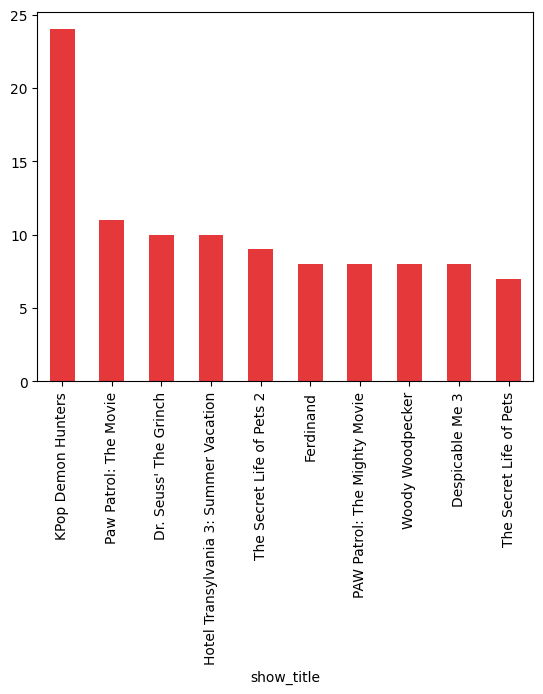

In [ ]:
#Filme mais visto no geral
df_filmes['show_title'].value_counts().head(10).plot(kind='bar')

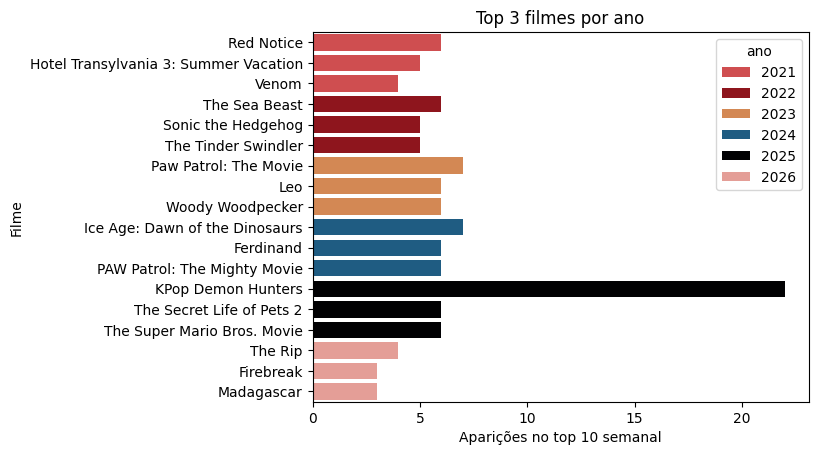

In [ ]:
sns.barplot(
    data=df_top_filmes_por_ano,
    x='count',
    y='show_title',
    hue='ano'
)
plt.title('Top 3 filmes por ano')
plt.xlabel('Aparições no top 10 semanal')
plt.ylabel('Filme')
plt.show()

### Séries

<Axes: xlabel='show_title'>

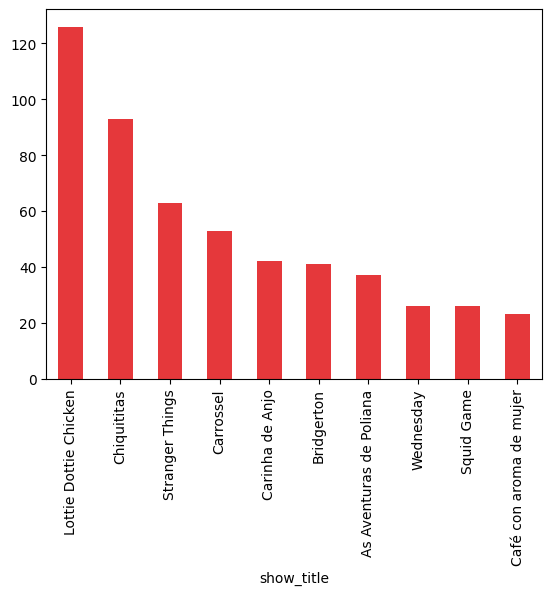

In [ ]:
#Série mais vista no geral
df_series['show_title'].value_counts().head(10).plot(kind='bar')

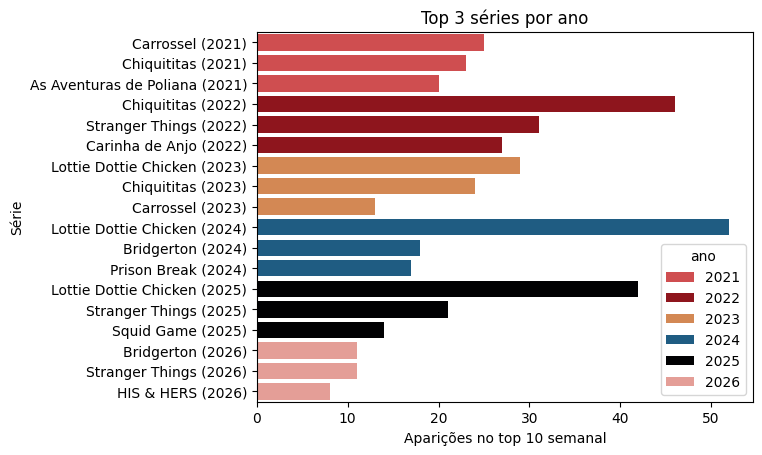

In [ ]:
sns.barplot(
    data=df_top_series_por_ano,
    x='count',
    y='serie_ano',
    hue='ano'
)
plt.title('Top 3 séries por ano')
plt.xlabel('Aparições no top 10 semanal')
plt.ylabel('Série')
plt.show()

## Cruzamento de dados

In [ ]:
df_squad=pd.read_csv('/content/dataset_final.csv')
df_squad.head()

,id,tipo,titulo,diretor,elenco,pais,adicionado_em,ano_lancamento,classificacao,genero,data_lancamento,duracao_em_min,temporadas,estacao
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,"Richard Johnson, Kirsten Johnson, Isla Sierck,...",US,2021-09-25,2020,12,Documentaries,2020-01-23,90.0,NaN,Verão
1,s2,TV Show,Blood & Water,Não Informado,"Ama Qamata, Khosi Ngema, Gail Mabalane, Dillon...",ZA,2021-09-24,2021,18,"International TV Shows, TV Dramas, TV Mysteries",2020-05-20,NaN,2.0,Outono
2,s3,TV Show,Ganglands,Não Informado,"Sami Bouajila, Tracy Gotoas, Salim Kéchiouche,...",FR,2021-09-24,2021,18,"Crime TV Shows, International TV Shows, TV Act...",2021-09-24,NaN,1.0,Primavera
3,s4,TV Show,Jailbirds New Orleans,Não Informado,Não Informado,US,2021-09-24,2021,18,"Docuseries, Reality TV",2021-09-24,NaN,1.0,Primavera
4,s5,TV Show,Kota Factory,Não Informado,"Jitendra Kumar, Mayur More, Ranjan Raj, Alam K...",IN,2021-09-24,2021,18,"International TV Shows, Romantic TV Shows, TV ...",2019-04-16,NaN,2.0,Outono


In [ ]:
#Renomear colunas que serão usadas pro merge
df_squad.rename(columns={
    'titulo':'show_title'
}, inplace=True)
df_squad.head(5)

,id,tipo,show_title,diretor,elenco,pais,adicionado_em,ano_lancamento,classificacao,genero,data_lancamento,duracao_em_min,temporadas,estacao
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,"Richard Johnson, Kirsten Johnson, Isla Sierck,...",US,2021-09-25,2020,12,Documentaries,2020-01-23,90.0,NaN,Verão
1,s2,TV Show,Blood & Water,Não Informado,"Ama Qamata, Khosi Ngema, Gail Mabalane, Dillon...",ZA,2021-09-24,2021,18,"International TV Shows, TV Dramas, TV Mysteries",2020-05-20,NaN,2.0,Outono
2,s3,TV Show,Ganglands,Não Informado,"Sami Bouajila, Tracy Gotoas, Salim Kéchiouche,...",FR,2021-09-24,2021,18,"Crime TV Shows, International TV Shows, TV Act...",2021-09-24,NaN,1.0,Primavera
3,s4,TV Show,Jailbirds New Orleans,Não Informado,Não Informado,US,2021-09-24,2021,18,"Docuseries, Reality TV",2021-09-24,NaN,1.0,Primavera
4,s5,TV Show,Kota Factory,Não Informado,"Jitendra Kumar, Mayur More, Ranjan Raj, Alam K...",IN,2021-09-24,2021,18,"International TV Shows, Romantic TV Shows, TV ...",2019-04-16,NaN,2.0,Outono


In [ ]:
#juntar tabelas
df_squad_filmes = df_squad.merge(df_filmes, how='inner', on='show_title')
df_squad_filmes.head()

,id,tipo,show_title,diretor,elenco,pais,adicionado_em,ano_lancamento,classificacao,genero,...,temporadas,estacao,country_name,country_iso2,week,category,weekly_rank,season_title,cumulative_weeks_in_top_10,ano
0,s7,Movie,My Little Pony: A New Generation,José Luis Ucha,"Vanessa Hudgens, Kimiko Glenn, James Marsden, ...","CA, IE",2021-09-24,2021,10,Children & Family Movies,...,NaN,Primavera,Brazil,BR,2021-10-03,Films,2,NaN,2,2021
1,s7,Movie,My Little Pony: A New Generation,José Luis Ucha,"Vanessa Hudgens, Kimiko Glenn, James Marsden, ...","CA, IE",2021-09-24,2021,10,Children & Family Movies,...,NaN,Primavera,Brazil,BR,2021-09-26,Films,5,NaN,1,2021
2,s10,Movie,The Starling,Theodore Melfi,"Melissa McCarthy, Chris O'Dowd, Kevin Kline, T...","CA, US",2021-09-24,2021,12,"Comedies, Dramas",...,NaN,Primavera,Brazil,BR,2021-10-03,Films,5,NaN,2,2021
3,s10,Movie,The Starling,Theodore Melfi,"Melissa McCarthy, Chris O'Dowd, Kevin Kline, T...","CA, US",2021-09-24,2021,12,"Comedies, Dramas",...,NaN,Primavera,Brazil,BR,2021-09-26,Films,4,NaN,1,2021
4,s14,Movie,Confessions of an Invisible Girl,Bruno Garotti,"Klara Castanho, Gabriel Lima, Júlia Gomes, Mar...",BR,2021-09-22,2021,10,"Children & Family Movies, Comedies",...,NaN,Primavera,Brazil,BR,2021-10-03,Films,6,NaN,2,2021


In [ ]:
#juntar tabelas
df_squad_series = df_squad.merge(df_series, how='inner', on='show_title')
df_squad_series.shape

(672, 22)

### Análise Gênero - Filmes

In [ ]:
df_squad_filmes['show_title'].value_counts()

,count
show_title,
Hotel Transylvania 3: Summer Vacation,10
Dr. Seuss' The Grinch,10
The Secret Life of Pets 2,9
Woody Woodpecker,8
The Croods,7
...,...
The Hurricane Heist,1
The Invitation,1
The Salvation,1


In [ ]:
#Separar gêneros para contar individualmente
df_squad_filmes['genero'] = df_squad_filmes['genero'].str.split(', ')
df_squad_filmes = df_squad_filmes.explode('genero')

In [ ]:
df_squad_filmes['genero'].value_counts().head(10)

,count
genero,
Comedies,127
Action & Adventure,117
Children & Family Movies,102
Dramas,73
International Movies,68
Thrillers,33
Romantic Movies,30
Horror Movies,24
Independent Movies,20


In [ ]:
df_squad_filmes.describe(include='all')

,id,tipo,show_title,diretor,elenco,pais,adicionado_em,ano_lancamento,classificacao,genero,...,temporadas,estacao,country_name,country_iso2,week,category,weekly_rank,season_title,cumulative_weeks_in_top_10,ano
count,704,704,704,704,704,704,704,704.000000,704,704,...,49.000000,704,704,704,704,704,704.000000,0,704.000000,704
unique,189,2,189,168,188,59,131,NaN,7,34,...,NaN,5,1,1,173,1,NaN,0,NaN,6
top,s7009,Movie,Hotel Transylvania 3: Summer Vacation,Não Informado,"Benedict Cumberbatch, Rashida Jones, Kenan Tho...",US,2021-07-01,NaN,10,Comedies,...,NaN,Inverno,Brazil,BR,2021-08-08,Films,NaN,NaN,NaN,2021
freq,20,655,20,61,20,369,21,NaN,237,127,...,NaN,240,704,704,19,704,NaN,NaN,NaN,228
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2014.651989,NaN,NaN,...,1.489796,NaN,NaN,NaN,NaN,NaN,5.893466,NaN,1.971591,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.316143,NaN,NaN,...,0.868966,NaN,NaN,NaN,NaN,NaN,2.809507,NaN,1.637675,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1956.000000,NaN,NaN,...,1.000000,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,1.000000,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2013.000000,NaN,NaN,...,1.000000,NaN,NaN,NaN,NaN,NaN,4.000000,NaN,1.000000,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2018.000000,NaN,NaN,...,1.000000,NaN,NaN,NaN,NaN,NaN,6.000000,NaN,1.000000,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2020.000000,NaN,NaN,...,1.000000,NaN,NaN,NaN,NaN,NaN,8.000000,NaN,2.000000,NaN


In [ ]:
df_squad_filmes['ano'].value_counts().sort_index()
#Interpretar como: Quais filmes do nosso dataset aparecem na contagem da netflix até hoje

,count
ano,
2021,228
2022,92
2023,135
2024,117
2025,113
2026,19


In [ ]:
df_squad_filmes_ano = df_squad_filmes.groupby('ano')['classificacao'].value_counts().groupby(level=0).head(3)
df_squad_filmes_ano

ano   classificacao
2021  18               91
      16               47
      10               46
2022  10               29
      16               27
      18               15
2023  10               50
      16               30
      12               24
2024  10               51
      14               23
      18               18
2025  10               50
      16               23
      12               19
2026  10               11
      16                4
      12                2
Name: count, dtype: int64

In [ ]:
df_squad_filmes_ano = df_squad_filmes.groupby('ano')['genero'].value_counts().groupby(level=0).head(3)
df_squad_filmes_ano

ano   genero                  
2021  Action & Adventure          37
      International Movies        36
      Comedies                    35
2022  Action & Adventure          22
      Children & Family Movies    13
      Comedies                    13
2023  Comedies                    29
      Children & Family Movies    23
      Action & Adventure          21
2024  Comedies                    19
      Children & Family Movies    16
      International Movies        16
2025  Comedies                    27
      Children & Family Movies    22
      Action & Adventure          18
2026  Children & Family Movies     6
      Action & Adventure           5
      Comedies                     4
Name: count, dtype: int64

In [ ]:
df_squad_filmes_ano = df_squad_filmes_ano.reset_index()

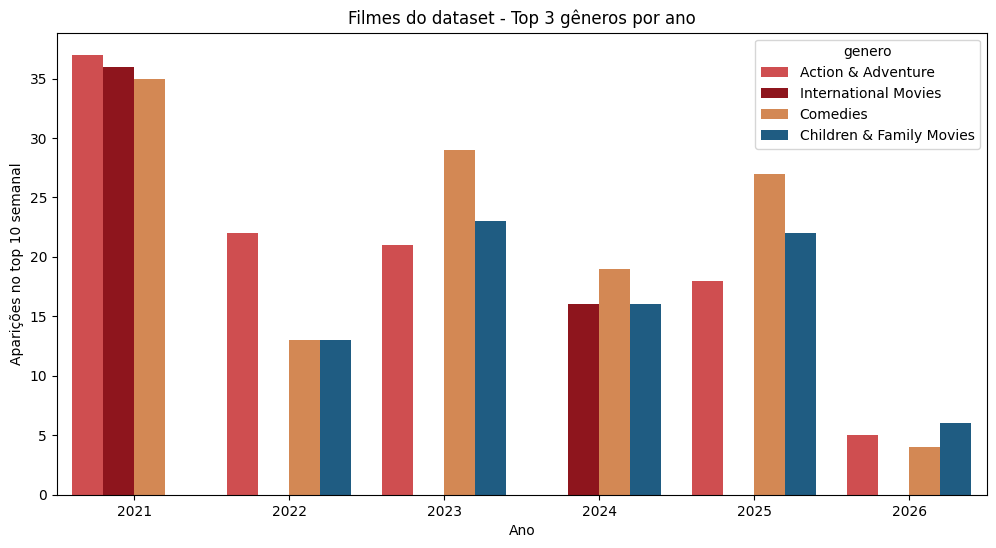

In [ ]:
plt.figure(figsize=(12,6))
sns.barplot(
    data=df_squad_filmes_ano,
    x='ano',
    y='count',
    hue='genero'
)
plt.title('Filmes do dataset - Top 3 gêneros por ano')
plt.ylabel('Aparições no top 10 semanal')
plt.xlabel('Ano')
plt.show()

#### **Achados**
- Temos filmes em nosso dataset que permanecem em algum momento do top 10 semanal até hoje.
- Filmes voltados ao público infantil, jovem e famílias são os mais recorrentes no top 10 (é a aposta segura)
- Ocasionalmente filmes internacionais e de classificação 18+ aparecem no top 10, no entanto não tem sido uma tendência nos últimos anos

### Análise gênero - Séries

In [ ]:
df_squad_series['show_title'].value_counts()

,count
show_title,
Stranger Things,63
Bridgerton,41
Squid Game,26
Manifest,22
Sintonia,21
...,...
The Chosen One,1
Gossip Girl,1
El Chavo,1


In [ ]:
df_squad_series['genero'] = df_squad_series['genero'].str.split(', ')
df_squad_series = df_squad_series.explode('genero')

In [ ]:
df_squad_series['genero'].value_counts().head(10)

,count
genero,
TV Dramas,375
International TV Shows,242
Crime TV Shows,151
Romantic TV Shows,145
TV Mysteries,142
TV Action & Adventure,139
TV Sci-Fi & Fantasy,128
TV Comedies,88
TV Horror,68


In [ ]:
df_squad_series.describe(include='all')

,id,tipo,show_title,diretor,elenco,pais,adicionado_em,ano_lancamento,classificacao,genero,...,temporadas,estacao,country_name,country_iso2,week,category,weekly_rank,season_title,cumulative_weeks_in_top_10,ano
count,1811,1811,1811,1811,1811,1811,1809,1811.000000,1811,1811,...,1691.000000,1811,1811,1811,1811,1811,1811.000000,1766,1811.000000,1811
unique,116,2,116,16,101,26,104,NaN,6,30,...,NaN,5,1,1,220,1,NaN,224,NaN,6
top,s3686,TV Show,Stranger Things,Não Informado,"Winona Ryder, David Harbour, Millie Bobby Brow...",US,2019-07-04,NaN,18,TV Dramas,...,NaN,Inverno,Brazil,BR,2021-07-04,TV,NaN,Stranger Things 4,NaN,2022
freq,189,1691,189,1691,189,973,189,NaN,995,375,...,NaN,513,1811,1811,21,1811,NaN,45,NaN,497
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019.059636,NaN,NaN,...,2.253696,NaN,NaN,NaN,NaN,NaN,5.402540,NaN,3.108780,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.931707,NaN,NaN,...,1.834283,NaN,NaN,NaN,NaN,NaN,2.976849,NaN,2.726945,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1979.000000,NaN,NaN,...,1.000000,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,1.000000,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019.000000,NaN,NaN,...,1.000000,NaN,NaN,NaN,NaN,NaN,3.000000,NaN,1.000000,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2020.000000,NaN,NaN,...,2.000000,NaN,NaN,NaN,NaN,NaN,5.000000,NaN,2.000000,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2021.000000,NaN,NaN,...,3.000000,NaN,NaN,NaN,NaN,NaN,8.000000,NaN,4.000000,NaN


In [ ]:
df_squad_series['ano'].value_counts().sort_index()
#Interpretar como: Quais séries do nosso dataset aparecem na contagem da netflix até hoje

,count
ano,
2021,316
2022,497
2023,397
2024,248
2025,260
2026,93


In [ ]:
df_squad_series_g_ano = df_squad_series.groupby('ano')['genero'].value_counts().groupby(level=0).head(3)
df_squad_series_g_ano

ano   genero                
2021  TV Dramas                 79
      International TV Shows    53
      Romantic TV Shows         32
2022  TV Dramas                 86
      TV Mysteries              75
      International TV Shows    62
2023  TV Dramas                 92
      International TV Shows    62
      TV Action & Adventure     50
2024  TV Dramas                 54
      Romantic TV Shows         30
      International TV Shows    23
2025  TV Dramas                 44
      International TV Shows    42
      TV Mysteries              26
2026  TV Dramas                 20
      TV Mysteries              18
      TV Sci-Fi & Fantasy       18
Name: count, dtype: int64

In [ ]:
df_squad_series.columns

Index(['id', 'tipo', 'show_title', 'diretor', 'elenco', 'pais',
       'adicionado_em', 'ano_lancamento', 'classificacao', 'genero',
       'data_lancamento', 'duracao_em_min', 'temporadas', 'estacao',
       'country_name', 'country_iso2', 'week', 'category', 'weekly_rank',
       'season_title', 'cumulative_weeks_in_top_10', 'ano'],
      dtype='object')

In [ ]:
df_squad_series_c_ano = df_squad_series.groupby('ano')['classificacao'].value_counts().groupby(level=0).head(3)
df_squad_series_c_ano

ano   classificacao
2021  18               223
      14                70
      10                21
2022  14               254
      18               230
      16                10
2023  18               249
      14               112
      10                18
2024  18               131
      14                64
      12                35
2025  18               130
      14               111
      10                11
2026  14                54
      18                32
      16                 6
Name: count, dtype: int64

In [ ]:
df_squad_series_c_ano = df_squad_series_c_ano.reset_index()
df_squad_series_c_ano.head()

,ano,classificacao,count
0,2021,18,223
1,2021,14,70
2,2021,10,21
3,2022,14,254
4,2022,18,230


In [ ]:
df_squad_series_g_ano = df_squad_series_g_ano.reset_index()

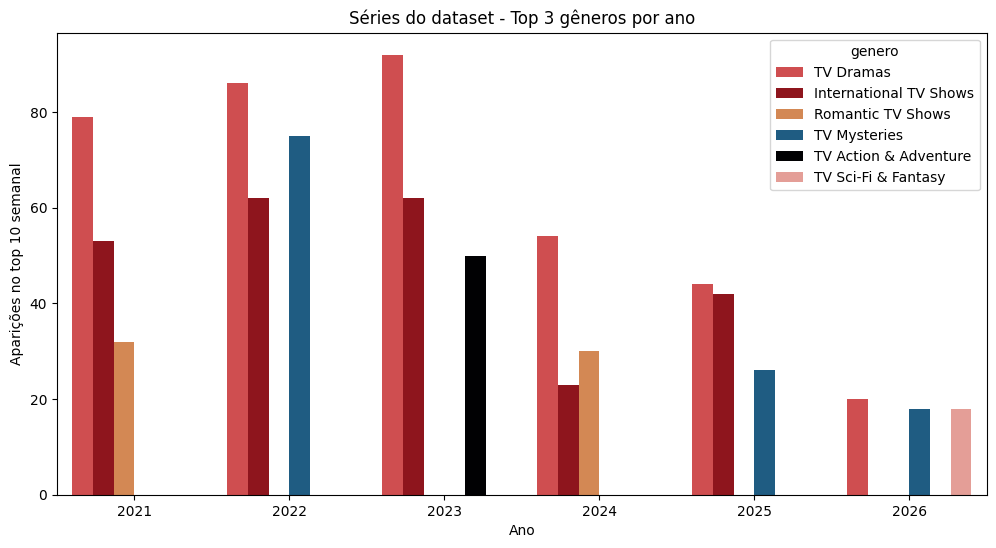

In [ ]:
plt.figure(figsize=(12,6))
sns.barplot(
    data=df_squad_series_g_ano,
    x='ano',
    y='count',
    hue='genero'
)
plt.title('Séries do dataset - Top 3 gêneros por ano')
plt.ylabel('Aparições no top 10 semanal')
plt.xlabel('Ano')
plt.show()

#### Achados

- Assim como nos filmes, em nosso dataset temos séries que que permanecem em algum momento do top 10 semanal até hoje.
- As séries com maior público são voltadas em sua maioria para o público adulto.
- O gênero com maior recorrência ao longo dos anos é drama, seguido de séries internacionais.